
# EPInformer-seq per-cell performance — pred vs. observed scatters

All 11 Roadmap cell types trained as independent `PerCellProfileNet` checkpoints
(no FiLM, no cell embedding — one model per cell). Per-rep ENCODE BAMs
(ENCODE-recommended single rep per assay). Test set = leave-chrom-out fold 10
(chr11 + chr21), peaks = DNase ∪ H3K27ac summit union.

This notebook visualises **predicted vs. observed `log10(total reads + 1)`** on
the held-out test set for each cell × each channel (DNase, H3K27ac) plus the
composite enhancer-activity scalar `0.5 · (log10(D+1) + log10(H+1))` (geometric
mean on the log scale). One hex-bin scatter per panel with the per-cell
Pearson r overlaid.

**Per-cell ckpts**: `_epinformerseq_v2/per_cell/<cell>/main.pt`
**Per-cell bias**: `_epinformerseq_v2/bias/<cell>/bias.pt`
**Test predictions**: `_epinformerseq_v2/per_cell/<cell>/test_preds.csv`


## Setup


In [1]:

import os, json
from pathlib import Path
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats

mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10, 'axes.titlesize': 11,
})

CELLS = ['K562', 'GM12878', 'HepG2', 'A549', 'H1', 'HeLa',
         'HMEC', 'HSMM', 'HUVEC', 'NHEK', 'NHLF']
PER_CELL_DIR = Path('_epinformerseq_v2/per_cell')

def load_summary(cell):
    return json.load(open(PER_CELL_DIR / cell / 'summary.json'))

def load_preds(cell):
    return pd.read_csv(PER_CELL_DIR / cell / 'test_preds.csv')

# Sanity check
for c in CELLS:
    p = PER_CELL_DIR / c / 'test_preds.csv'
    assert p.exists(), f'missing {p}'
print(f'All {len(CELLS)} cells found at {PER_CELL_DIR}')


All 11 cells found at _epinformerseq_v2/per_cell



## § 1. Per-cell summary table

Pearson r on count-head predictions vs observed totals on the test set, per
channel and on the composite. Composite = `0.5 · (log10(D+1) + log10(H+1))`,
which is `log10` of the geometric mean of the two channel totals (the same
"enhancer activity" used elsewhere).


In [2]:

rows = []
for c in CELLS:
    s = load_summary(c)
    df = load_preds(c)
    pred_c = 0.5 * (df['pred_log10_dnase'].values + df['pred_log10_h3k27ac'].values)
    obs_c  = 0.5 * (df['obs_log10_dnase'].values  + df['obs_log10_h3k27ac'].values)
    r_c = float(stats.pearsonr(pred_c, obs_c).statistic)
    rows.append({
        'cell':        c,
        'n_test':      s['test_n'],
        'r_DNase':     s['test_r_dnase_count'],
        'r_H3K27ac':   s['test_r_h3k27ac_count'],
        'r_composite': r_c,
    })

perf = pd.DataFrame(rows).set_index('cell')
mean_row = pd.DataFrame({
    'n_test':      [perf['n_test'].sum()],
    'r_DNase':     [perf['r_DNase'].mean()],
    'r_H3K27ac':   [perf['r_H3K27ac'].mean()],
    'r_composite': [perf['r_composite'].mean()],
}, index=['mean'])
perf_with_mean = pd.concat([perf, mean_row])
perf_with_mean.round(3)


,n_test,r_DNase,r_H3K27ac,r_composite
K562,8623,0.848,0.745,0.788
GM12878,5280,0.699,0.619,0.639
HepG2,5230,0.901,0.747,0.807
A549,9819,0.834,0.744,0.794
H1,8164,0.881,0.658,0.777
HeLa,5997,0.853,0.755,0.795
HMEC,5352,0.886,0.713,0.733
HSMM,8239,0.703,0.625,0.660
HUVEC,5175,0.851,0.764,0.735
NHEK,5914,0.869,0.727,0.755



## § 2. Per-channel r bar chart


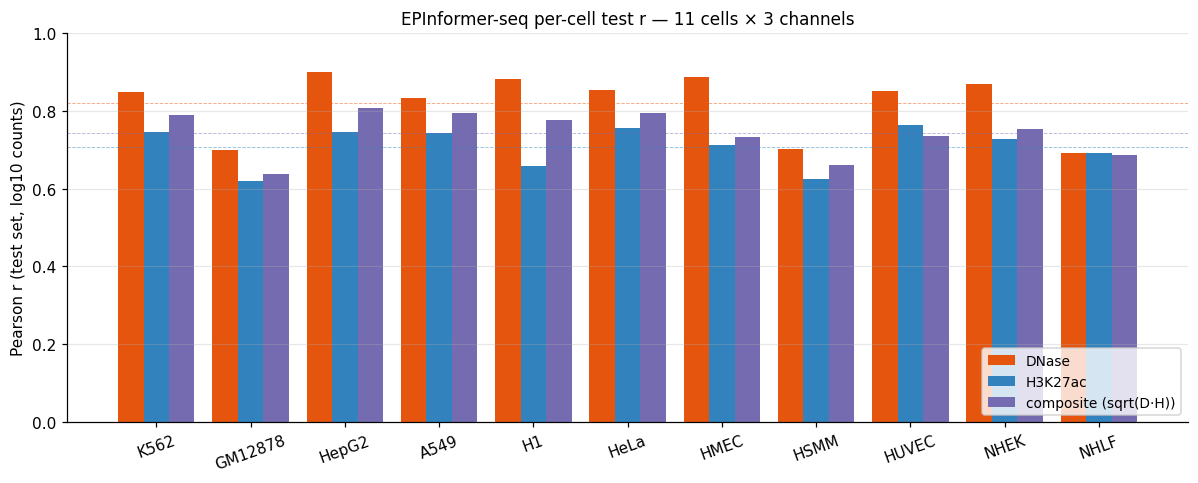

Mean across 11 cells:
  DNase     : 0.820
  H3K27ac   : 0.708
  composite : 0.743


In [3]:

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(CELLS))
w = 0.27
ax.bar(x - w, perf['r_DNase'].values,     w, label='DNase',           color='#e6550d')
ax.bar(x,     perf['r_H3K27ac'].values,   w, label='H3K27ac',         color='#3182bd')
ax.bar(x + w, perf['r_composite'].values, w, label='composite (sqrt(D·H))', color='#756bb1')
ax.set_xticks(x); ax.set_xticklabels(CELLS, rotation=20)
ax.set_ylim(0, 1)
ax.set_ylabel('Pearson r (test set, log10 counts)')
ax.set_title('EPInformer-seq per-cell test r — 11 cells × 3 channels')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.axhline(perf['r_DNase'].mean(),     color='#e6550d', linestyle='--', linewidth=0.6, alpha=0.5)
ax.axhline(perf['r_H3K27ac'].mean(),   color='#3182bd', linestyle='--', linewidth=0.6, alpha=0.5)
ax.axhline(perf['r_composite'].mean(), color='#756bb1', linestyle='--', linewidth=0.6, alpha=0.5)
plt.tight_layout(); plt.show()

print(f'Mean across 11 cells:')
print(f'  DNase     : {perf["r_DNase"].mean():.3f}')
print(f'  H3K27ac   : {perf["r_H3K27ac"].mean():.3f}')
print(f'  composite : {perf["r_composite"].mean():.3f}')



## § 3. DNase channel — pred vs observed, all 11 cells


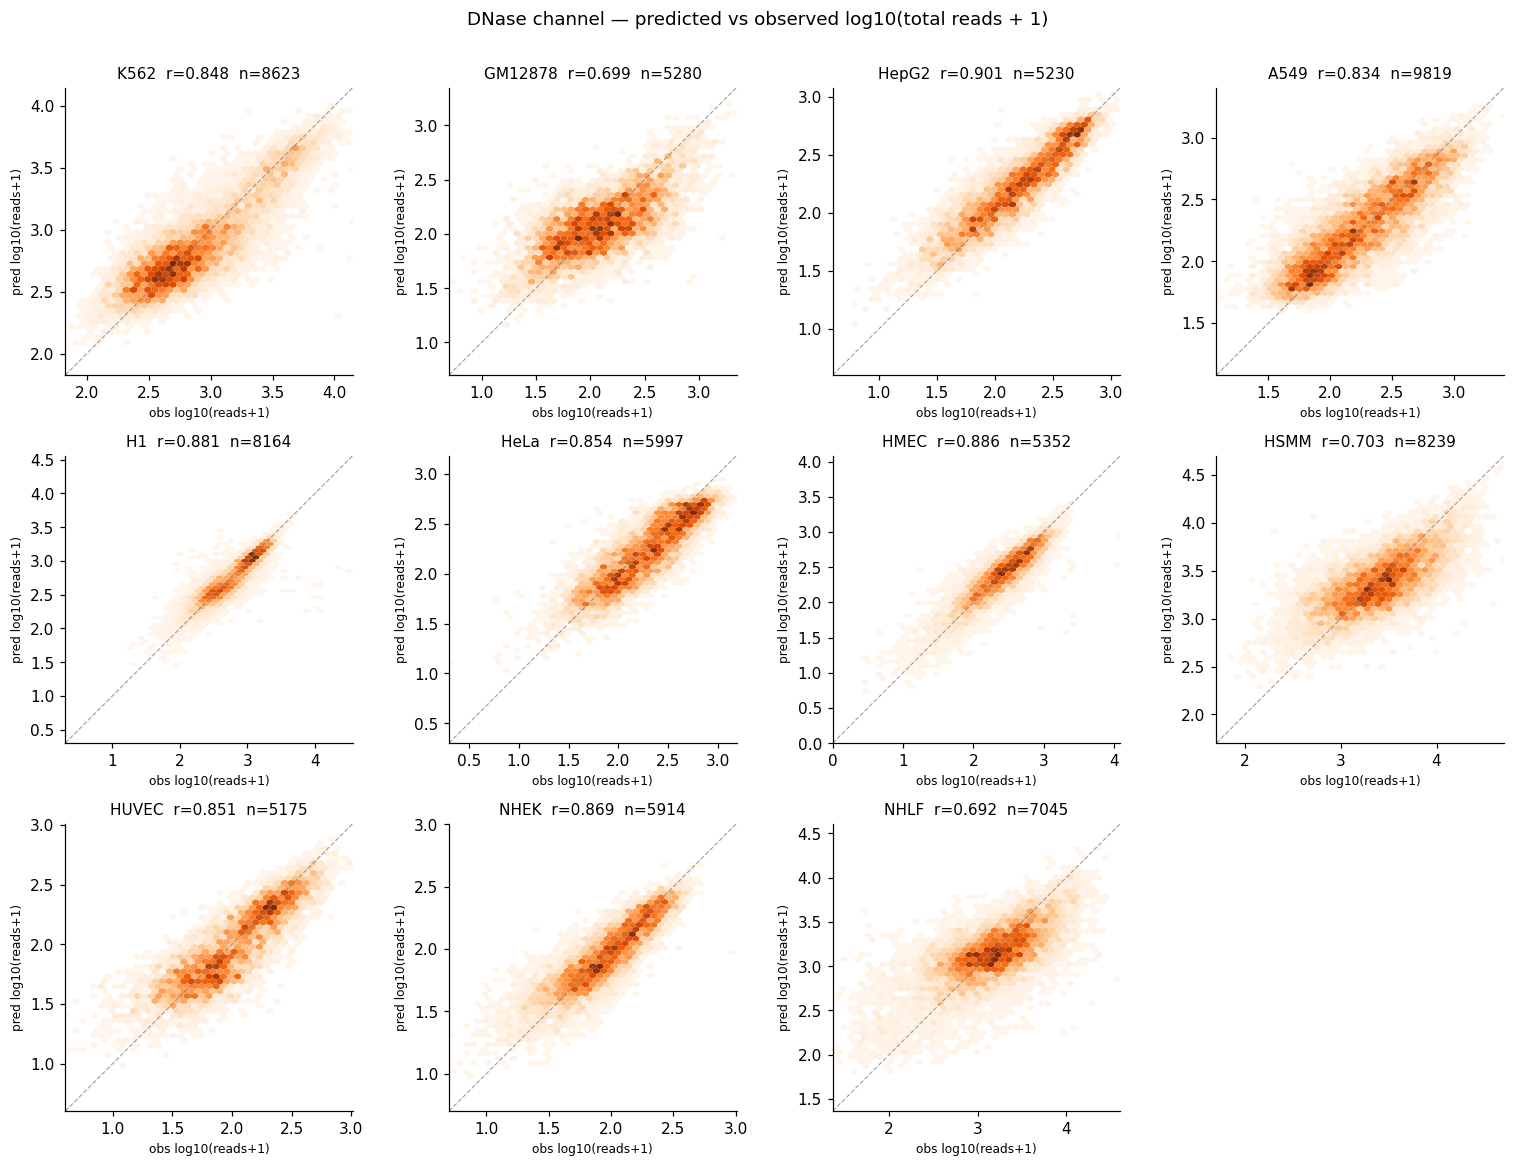

In [4]:

n_cells = len(CELLS)
n_cols = 4
n_rows = (n_cells + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 3.5 * n_rows),
                         sharex=False, sharey=False)
axes = axes.flatten()
for i, cell in enumerate(CELLS):
    df = load_preds(cell)
    obs  = df['obs_log10_dnase'].values
    pred = df['pred_log10_dnase'].values
    r = float(stats.pearsonr(pred, obs).statistic)
    ax = axes[i]
    ax.hexbin(obs, pred, gridsize=40, mincnt=1, cmap='Oranges', linewidths=0)
    lo = float(min(obs.min(), pred.min())); hi = float(max(obs.max(), pred.max()))
    ax.plot([lo, hi], [lo, hi], color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(f'{cell}  r={r:.3f}  n={len(obs)}', fontsize=10)
    ax.set_xlabel('obs log10(reads+1)', fontsize=8)
    ax.set_ylabel('pred log10(reads+1)', fontsize=8)
for j in range(n_cells, len(axes)):
    axes[j].axis('off')
fig.suptitle('DNase channel — predicted vs observed log10(total reads + 1)', y=1.005)
plt.tight_layout(); plt.show()



## § 4. H3K27ac channel — pred vs observed, all 11 cells


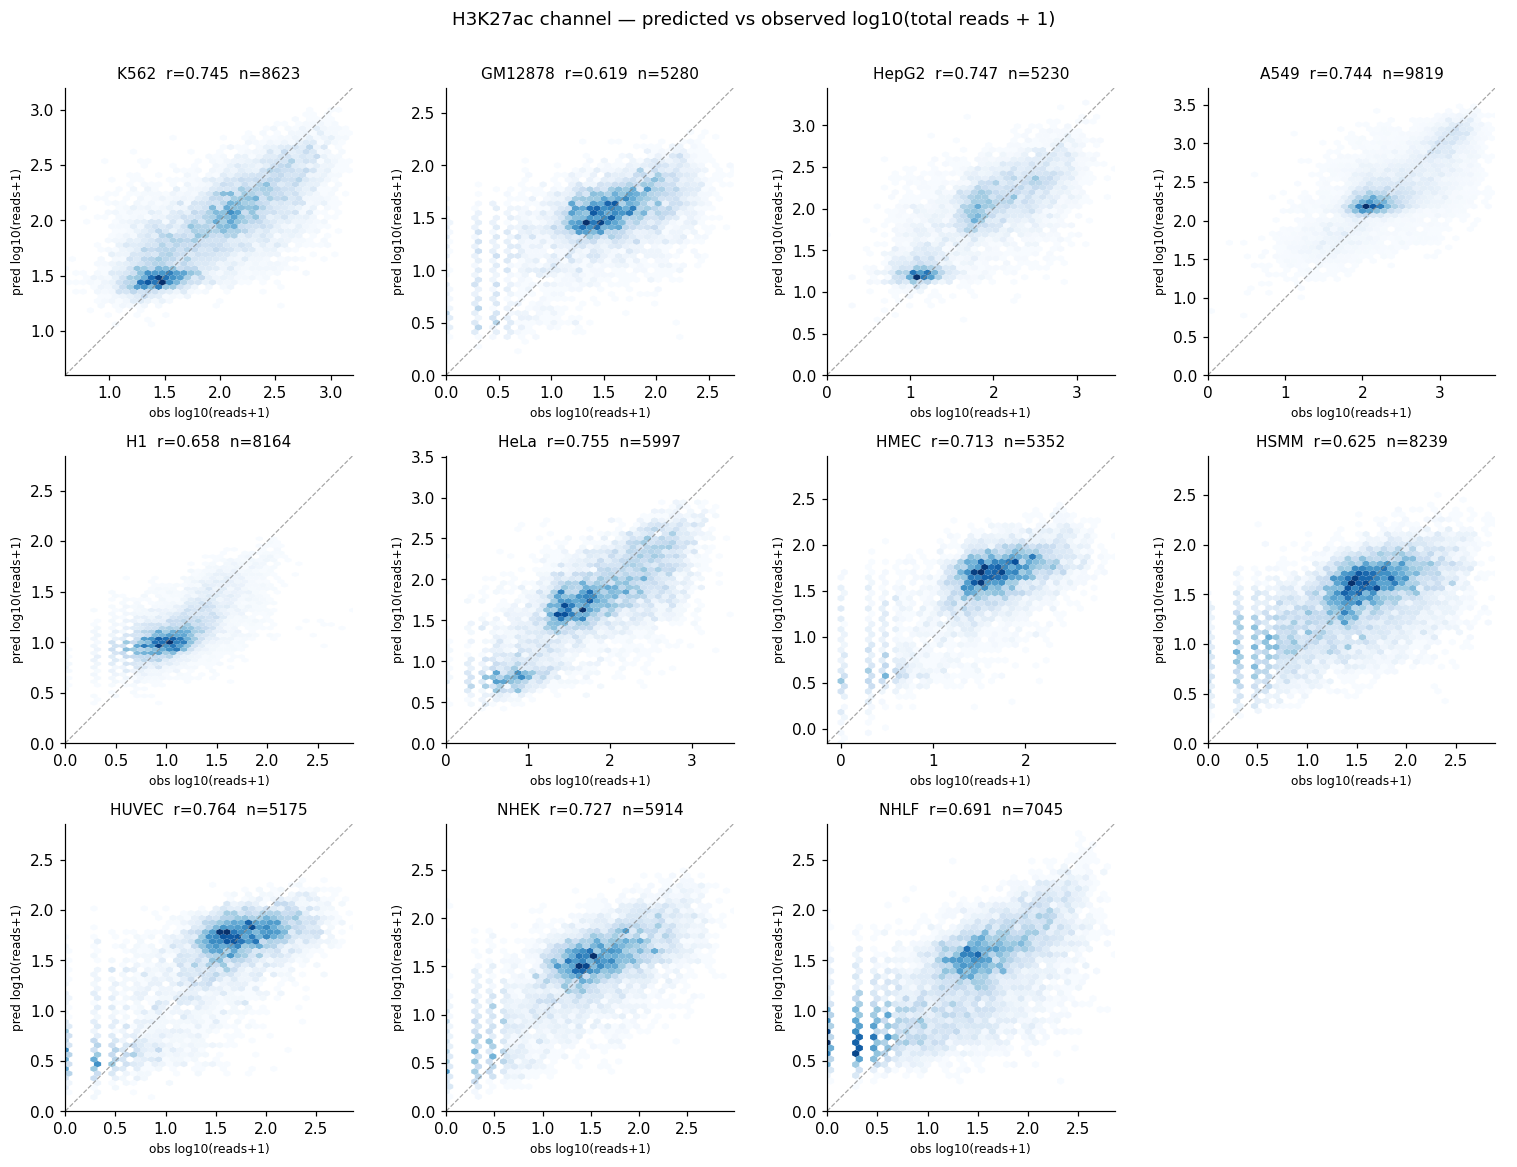

In [5]:

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 3.5 * n_rows),
                         sharex=False, sharey=False)
axes = axes.flatten()
for i, cell in enumerate(CELLS):
    df = load_preds(cell)
    obs  = df['obs_log10_h3k27ac'].values
    pred = df['pred_log10_h3k27ac'].values
    r = float(stats.pearsonr(pred, obs).statistic)
    ax = axes[i]
    ax.hexbin(obs, pred, gridsize=40, mincnt=1, cmap='Blues', linewidths=0)
    lo = float(min(obs.min(), pred.min())); hi = float(max(obs.max(), pred.max()))
    ax.plot([lo, hi], [lo, hi], color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(f'{cell}  r={r:.3f}  n={len(obs)}', fontsize=10)
    ax.set_xlabel('obs log10(reads+1)', fontsize=8)
    ax.set_ylabel('pred log10(reads+1)', fontsize=8)
for j in range(n_cells, len(axes)):
    axes[j].axis('off')
fig.suptitle('H3K27ac channel — predicted vs observed log10(total reads + 1)', y=1.005)
plt.tight_layout(); plt.show()



## § 5. Composite enhancer activity (`sqrt(D · H)`) — pred vs observed


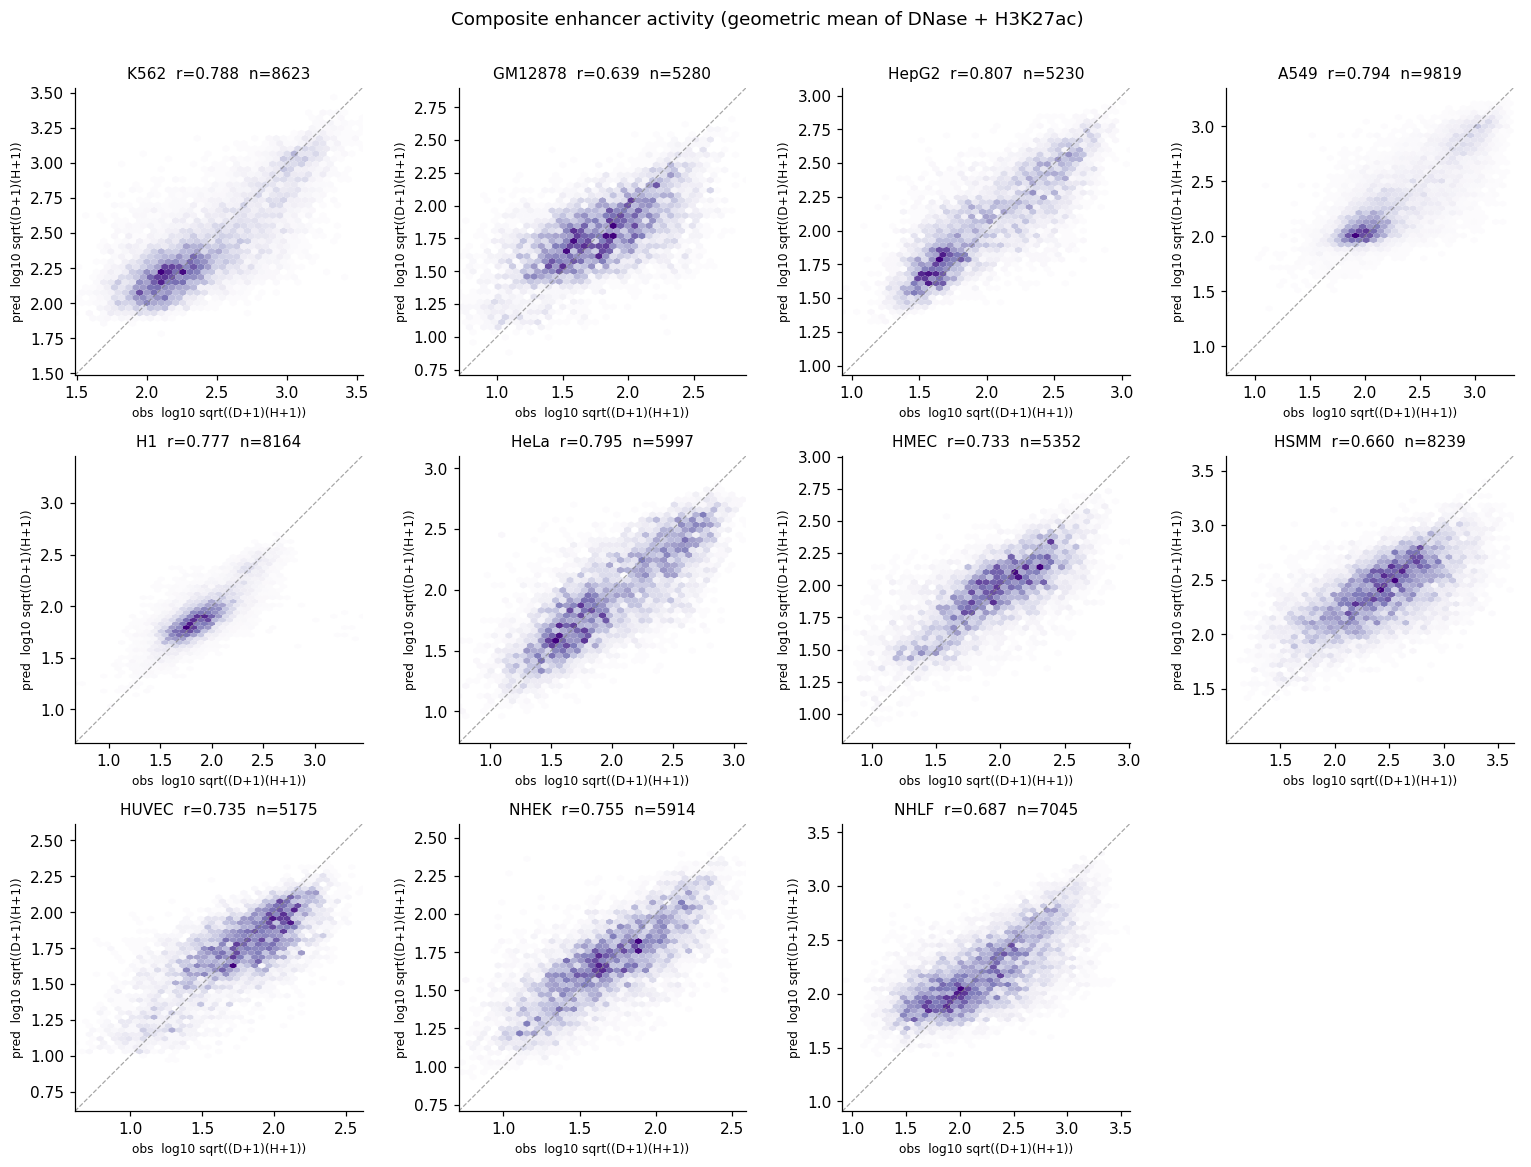

In [6]:

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 3.5 * n_rows),
                         sharex=False, sharey=False)
axes = axes.flatten()
for i, cell in enumerate(CELLS):
    df = load_preds(cell)
    pred = 0.5 * (df['pred_log10_dnase'].values + df['pred_log10_h3k27ac'].values)
    obs  = 0.5 * (df['obs_log10_dnase'].values  + df['obs_log10_h3k27ac'].values)
    r = float(stats.pearsonr(pred, obs).statistic)
    ax = axes[i]
    ax.hexbin(obs, pred, gridsize=40, mincnt=1, cmap='Purples', linewidths=0)
    lo = float(min(obs.min(), pred.min())); hi = float(max(obs.max(), pred.max()))
    ax.plot([lo, hi], [lo, hi], color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(f'{cell}  r={r:.3f}  n={len(obs)}', fontsize=10)
    ax.set_xlabel('obs  log10 sqrt((D+1)(H+1))', fontsize=8)
    ax.set_ylabel('pred  log10 sqrt((D+1)(H+1))', fontsize=8)
for j in range(n_cells, len(axes)):
    axes[j].axis('off')
fig.suptitle('Composite enhancer activity (geometric mean of DNase + H3K27ac)', y=1.005)
plt.tight_layout(); plt.show()



## § 6. Observations

- **Best cells**: HepG2 (DNase r=0.901), HMEC (0.886), H1 (0.881) — clean
  ENCODE depth + sharper peak sets help.
- **Worst cells**: NHLF (0.692 DNase), HSMM (0.703 DNase), GM12878
  (0.699 DNase) — all have noisier H3K27ac BAMs (shallow reps) and
  broader/messier peak unions (HSMM ~131K peaks vs typical ~80–90K).
- **DNase consistently outperforms H3K27ac** in every cell — DNase peaks are
  sharper, training counts are higher per peak, and the cut-site signal has
  less per-bp noise than ChIP-seq.
- **Composite tracks** sit between DNase and H3K27ac in r, reflecting that
  it averages the two channels' information.
